# PROYECTO FINAL — Entrega P1: Exploración y Preprocesamiento
### Curso: Introducción a Ciencia de Datos e Inteligencia Artificial — UTEC
### Dataset elegido: **Bank Marketing** (con atributos socioeconómicos — `bank-additional-full.csv`)

**Integrantes:**

---

## 1. Contexto del Dataset

**Descripción del problema.**
El dataset proviene de campañas de *tele-marketing directo* de una institución bancaria portuguesa. El banco llamaba
repetidamente a sus clientes para ofrecerles un **depósito a plazo fijo** (*term deposit*). Cada fila representa un
contacto telefónico con un cliente e incluye (a) datos demográficos del cliente, (b) datos de la campaña de contacto
actual y de campañas previas, y (c) cinco indicadores macroeconómicos de Portugal (tasa de variación del empleo,
índice de precios al consumidor, índice de confianza del consumidor, tasa euríbor a 3 meses y número de empleados)
correspondientes a la fecha del contacto.

**Fuente del dataset.**
UCI Machine Learning Repository — *Bank Marketing Data Set*, recolectado por S. Moro, P. Cortez y P. Rita (2014),
"A Data-Driven Approach to Predict the Success of Bank Telemarketing", *Decision Support Systems*. Usamos la versión
`bank-additional-full.csv` (41,188 registros, 20 variables predictoras + 1 variable objetivo), que es la versión
más completa (incluye los indicadores socioeconómicos) y con todos los registros disponibles (a diferencia de
`bank-additional.csv`, que es solo un 10% de muestra).

**Objetivo del análisis.**
Predecir si un cliente **suscribirá o no un depósito a plazo fijo** luego de ser contactado (variable objetivo
binaria `y`: `"yes"` / `"no"`). Es un problema de **clasificación binaria**. En esta primera entrega (P1) nos
enfocamos en comprender la estructura de los datos, limpiarlos y explorarlos estadísticamente; el modelado
predictivo se abordará en la Entrega P2.

**Nota importante sobre la variable `duration`:** la documentación oficial del dataset advierte que la duración
de la llamada (`duration`) tiene una relación casi determinística con el resultado (si `duration = 0`, entonces
`y = "no"` necesariamente, porque la llamada nunca se realizó). Esta variable **no se conoce antes de realizar la
llamada**, por lo que en un escenario de predicción realista (antes de llamar al cliente) no debería usarse como
insumo del modelo. La incluimos en el EDA de esta entrega por su valor descriptivo, pero dejamos constancia de que
deberá excluirse (o tratarse con extremo cuidado) al construir el modelo predictivo en la Entrega P2.

## 2. Carga y Exploración Inicial

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42

df = pd.read_csv("../bank-additional/bank-additional-full.csv", sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
df.info()

Dimensiones del dataset: 41188 filas x 21 columnas
<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  floa

**Comentario:** el dataset tiene 41,188 filas y 21 columnas (20 predictoras + `y`). `pandas` no detecta
valores nulos (`NaN`) en ninguna columna porque, como veremos, los valores faltantes en este dataset no se
representan como celdas vacías sino con la categoría explícita `"unknown"` dentro de las variables categóricas.
Por eso no basta con `df.isnull()`; hay que revisar el contenido de cada columna categórica.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


In [ ]:
df.describe(include="object").T

/var/folders/8d/zj7wntq938x4bp7vf97gz8d00000gn/T/ipykernel_86706/1274302342.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
job,41188,12,admin.,10422
marital,41188,4,married,24928
education,41188,8,university.degree,12168
default,41188,3,no,32588
housing,41188,3,yes,21576
loan,41188,3,no,33950
contact,41188,2,cellular,26144
month,41188,10,may,13769
day_of_week,41188,5,thu,8623
poutcome,41188,3,nonexistent,35563


**Comentario:** las estadísticas descriptivas muestran, por ejemplo, que la edad promedio de los clientes
contactados es de ~40 años (mediana 38), que la duración promedio de llamada es de 258 segundos con una desviación
estándar (259) casi igual a la media (indicio de una distribución muy asimétrica hacia la derecha), y que `pdays`
tiene una mediana de 999 — el valor "centinela" que el propio dataset usa para indicar "cliente nunca contactado
antes" (lo profundizamos en la sección de preprocesamiento). En las variables categóricas, `job`, `education` y
`month` tienen más de 10 categorías, mientras que variables binarias como `housing`, `loan`, `contact` y el target
`y` tienen 2-3 categorías.

Valores NaN por columna:
No hay valores NaN explícitos en ninguna columna.

Porcentaje de valores 'unknown' (faltantes disfrazados) por columna:
default      20.87
education     4.20
housing       2.40
loan          2.40
job           0.80
marital       0.19
dtype: float64


/var/folders/8d/zj7wntq938x4bp7vf97gz8d00000gn/T/ipykernel_86706/3510165992.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_categoricas = df.select_dtypes(include="object").columns.drop("y")


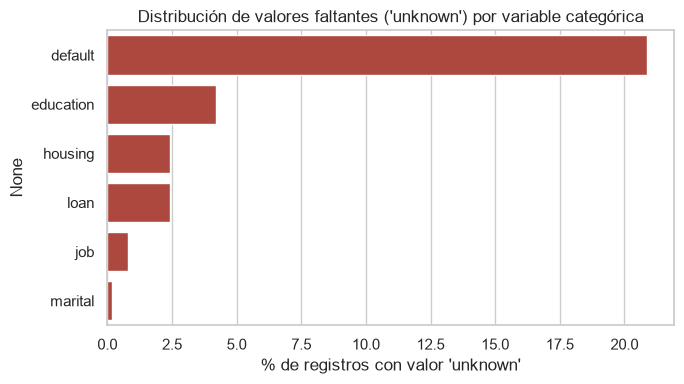

In [ ]:
# "Valores nulos" reales (NaN) — no existen en este dataset
nulos = df.isnull().sum()
print("Valores NaN por columna:")
print(nulos[nulos > 0] if nulos.sum() > 0 else "No hay valores NaN explícitos en ninguna columna.")

# Sin embargo, varias columnas categóricas usan la etiqueta "unknown" como marcador de dato faltante.
cols_categoricas = df.select_dtypes(include="object").columns.drop("y")
unknown_pct = (
    df[cols_categoricas]
    .apply(lambda col: (col == "unknown").mean() * 100)
    .sort_values(ascending=False)
)
unknown_pct = unknown_pct[unknown_pct > 0]
print("\nPorcentaje de valores 'unknown' (faltantes disfrazados) por columna:")
print(unknown_pct.round(2))

plt.figure(figsize=(7, 4))
sns.barplot(x=unknown_pct.values, y=unknown_pct.index, color="#c0392b")
plt.xlabel("% de registros con valor 'unknown'")
plt.title("Distribución de valores faltantes ('unknown') por variable categórica")
plt.tight_layout()
plt.show()

**Interpretación:** `default` (¿tiene crédito en mora?) concentra el mayor porcentaje de valores faltantes
(~20.9%), seguido de `education` (~4.2%), `housing` y `loan` (~2.4% cada una), `job` (~0.8%) y `marital` (~0.2%).
Ninguna columna numérica tiene valores faltantes. Esta visualización justifica la estrategia de tratamiento que
aplicaremos en la sección de preprocesamiento: dado que ninguna variable supera ~21% de faltantes y que el
"unknown" puede ser informativo por sí mismo (p. ej. no querer declarar si se tiene una deuda en mora podría
correlacionar con el comportamiento financiero del cliente), optamos por **conservar "unknown" como una categoría
válida más**, en lugar de eliminar filas o imputar un valor, evitando así perder ~21% de las observaciones por una
sola variable.

## 3. Preprocesamiento de los Datos (Data Wrangling)

### 3.1 Duplicados

In [ ]:
n_duplicados = df.duplicated().sum()
print(f"Número de filas totalmente duplicadas: {n_duplicados}")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dimensiones luego de eliminar duplicados: {df.shape}")

Número de filas totalmente duplicadas: 12
Dimensiones luego de eliminar duplicados: (41176, 21)


**Justificación:** se identificaron 12 filas exactamente duplicadas (mismos valores en las 21 columnas).
A diferencia de los "unknown", que pueden ser informativos, una fila duplicada no aporta información nueva: es
altamente improbable que dos clientes distintos coincidan en los 21 atributos por azar, por lo que lo más razonable
es que sean registros repetidos por error en la captura de datos. Al ser solo 12 de 41,188 filas (0.03%), eliminarlas
no genera pérdida de información relevante ni sesga la muestra.

### 3.2 Cambio de nombres de columnas

In [ ]:
df = df.rename(columns={
    "emp.var.rate": "emp_var_rate",
    "cons.price.idx": "cons_price_idx",
    "cons.conf.idx": "cons_conf_idx",
    "nr.employed": "nr_employed",
    "duration": "duration_sec",
    "campaign": "campaign_contacts",
    "previous": "previous_contacts",
})
df.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'duration_sec',
 'campaign_contacts',
 'pdays',
 'previous_contacts',
 'poutcome',
 'emp_var_rate',
 'cons_price_idx',
 'cons_conf_idx',
 'euribor3m',
 'nr_employed',
 'y']

**Justificación:** renombramos las tres columnas con puntos a `snake_case` para evitar ambigüedad con el
operador de acceso a atributos de pandas/Python. También renombramos `duration`, `campaign` y `previous` a nombres
más descriptivos (`duration_sec`, `campaign_contacts`, `previous_contacts`) para que el significado de cada
variable sea explícito sin tener que consultar el diccionario de datos.

### 3.3 Transformación de tipos de datos

In [ ]:
cat_cols = ["job", "marital", "education", "default", "housing", "loan",
            "contact", "month", "day_of_week", "poutcome", "y"]
for c in cat_cols:
    df[c] = df[c].astype("category")

df["y_binary"] = (df["y"] == "yes").astype(int)

df.dtypes

age                     int64
job                  category
marital              category
education            category
default              category
housing              category
loan                 category
contact              category
month                category
day_of_week          category
duration_sec            int64
campaign_contacts       int64
pdays                   int64
previous_contacts       int64
poutcome             category
emp_var_rate          float64
cons_price_idx        float64
cons_conf_idx         float64
euribor3m             float64
nr_employed           float64
y                    category
y_binary                int64
dtype: object

**Justificación:** convertimos las columnas de texto a tipo `category` en lugar de dejarlas como `object`.
Esto (a) reduce el uso de memoria porque pandas almacena internamente códigos enteros en vez de strings repetidos,
(b) dejar explícito para cualquier lector del notebook cuáles variables son categóricas nominales/ordinales, y
(c) habilita directamente funciones de pandas orientadas a categorías (`.cat.categories`, `value_counts` ordenado,
etc.). Además creamos `y_binary` (0/1) porque varias operaciones de EDA multivariado (correlación con el target,
promedios agrupados) requieren una representación numérica de la variable objetivo.

### 3.4 Tratamiento de la variable `pdays` (valor centinela 999)

In [ ]:
pct_nunca_contactado = (df["pdays"] == 999).mean() * 100
print(f"Porcentaje de clientes con pdays = 999 (nunca contactados antes): {pct_nunca_contactado:.2f}%")


df["contactado_antes"] = np.where(df["pdays"] == 999, "no", "si")
df["contactado_antes"] = df["contactado_antes"].astype("category")

Porcentaje de clientes con pdays = 999 (nunca contactados antes): 96.32%


**Justificación:** el 96.32% de los registros tiene `pdays = 999`, que **no** es un número real de días sino
un código que significa "el cliente nunca fue contactado en una campaña anterior". Si dejáramos `pdays` como una
variable puramente numérica, un modelo o una estadística descriptiva (media, boxplot) interpretaría 999 como un
valor extremo real, distorsionando por completo la escala (la media pasaría de reflejar "días desde el último
contacto" a estar dominada por el código 999). Por ello separamos la información en dos partes: (1) un flag
categórico `contactado_antes` (sí/no) que captura el hecho relevante — si hubo o no contacto previo — y (2) dejamos
`pdays` intacta para el subconjunto de análisis donde específicamente se estudia cuántos días pasaron entre
contactos reales (excluyendo los 999). Esta decisión también es consistente con lo que documenta la fuente
original del dataset.

### 3.5 Enriquecimiento de datos — Creación de nuevas variables

In [ ]:
bins_edad = [17, 25, 35, 45, 55, 65, 100]
etiquetas_edad = ["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
df["grupo_edad"] = pd.cut(df["age"], bins=bins_edad, labels=etiquetas_edad, right=True)

df["intensidad_campania"] = pd.cut(
    df["campaign_contacts"],
    bins=[0, 1, 3, 100],
    labels=["1 contacto", "2-3 contactos", "4+ contactos"],
)


df["exito_campania_previa"] = (df["poutcome"] == "success").astype(int)

df[["age", "grupo_edad", "campaign_contacts", "intensidad_campania", "poutcome", "exito_campania_previa"]].head(8)

,age,grupo_edad,campaign_contacts,intensidad_campania,poutcome,exito_campania_previa
0,56,56-65,1,1 contacto,nonexistent,0
1,57,56-65,1,1 contacto,nonexistent,0
2,37,36-45,1,1 contacto,nonexistent,0
3,40,36-45,1,1 contacto,nonexistent,0
4,56,56-65,1,1 contacto,nonexistent,0
5,45,36-45,1,1 contacto,nonexistent,0
6,59,56-65,1,1 contacto,nonexistent,0
7,41,36-45,1,1 contacto,nonexistent,0


**Justificación de las nuevas variables:**
- `grupo_edad`: discretizar la edad en tramos de 10 años (con un tramo abierto "66+") facilita comparar tasas de
  conversión entre segmentos demográficos en los gráficos de barras/boxplots comparativos, en lugar de trabajar con
  41,188 valores continuos distintos.
- `intensidad_campania`: agrupa el número de contactos en 3 niveles con significado de negocio (contacto único,
  seguimiento moderado, insistencia alta). Es más fácil de comunicar en una presentación que una variable continua
  con cola larga (máximo 56 contactos, mediana 2).
- `exito_campania_previa`: extrae explícitamente la señal más fuerte de `poutcome` (ver el análisis de
  correlación en la sección multivariada) en formato binario 0/1, listo para usarse en modelos y agregaciones
  numéricas.

No fue posible calcular la edad a partir de una fecha de nacimiento (ejemplo típico de enriquecimiento) porque el
dataset no incluye fechas de nacimiento; en su lugar, `age` ya viene pre-calculada por la fuente original.

## 4. Análisis Exploratorio de Datos (EDA)

### 4.a Análisis Univariado

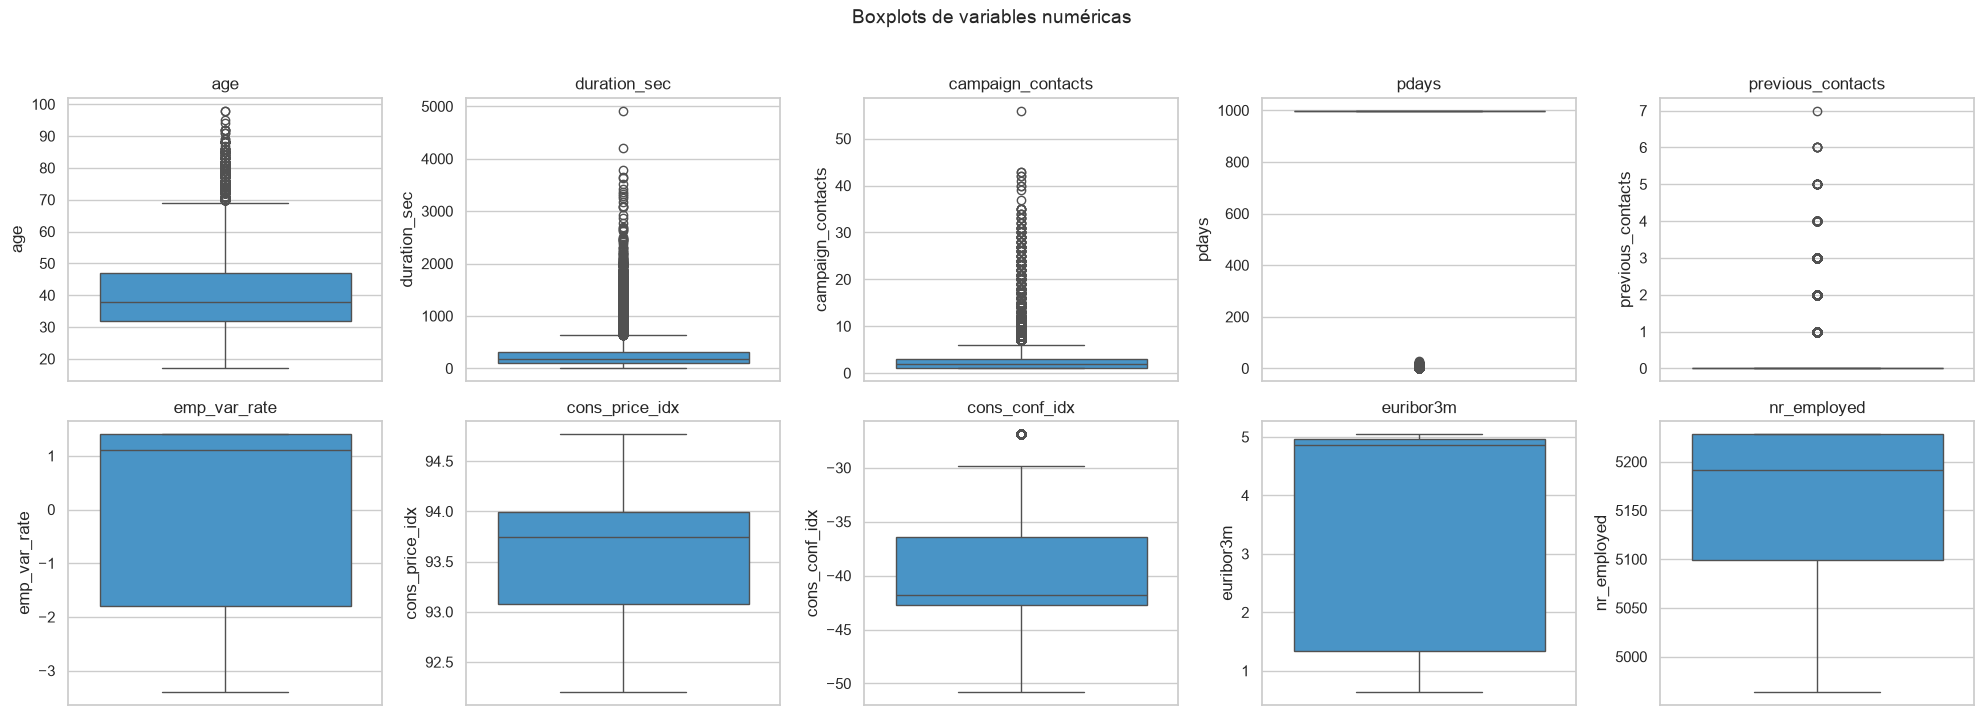

In [ ]:
numeric_cols = ["age", "duration_sec", "campaign_contacts", "pdays", "previous_contacts",
                "emp_var_rate", "cons_price_idx", "cons_conf_idx", "euribor3m", "nr_employed"]

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color="#3498db")
    ax.set_title(col)
plt.suptitle("Boxplots de variables numéricas", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

**Hallazgos por variable (boxplots):**
- **`age`**: mediana 38 años, con varios outliers por encima de ~70 años (clientes de la tercera edad); la caja es
  relativamente compacta, indicando que la mayoría de clientes están entre los 32 y 47 años.
- **`duration_sec`**: fuerte asimetría a la derecha, con una gran cantidad de outliers por encima de los 600-700
  segundos y algunos valores extremos cercanos a 4,900 segundos (~82 minutos). Esto es esperable: la mayoría de
  llamadas son cortas (colgadas rápido o rechazadas) y solo unas pocas se extienden mucho (clientes muy interesados).
- **`campaign_contacts`**: extremadamente sesgada a la derecha; la mediana es 2 contactos pero hay outliers hasta 56.
  Sugiere que insistir demasiadas veces con el mismo cliente es la excepción, no la norma.
- **`pdays`**: dominado por el valor centinela 999 (percentil 75 = 999), lo que hace que el boxplot casi no muestre
  variabilidad — confirma la necesidad del flag `contactado_antes` creado en el preprocesamiento.
- **`previous_contacts`**: la mayoría de clientes tiene 0 contactos previos (consistente con que ~96% nunca fue
  contactado antes), con outliers hasta 7.
- **`emp_var_rate`, `cons_price_idx`, `cons_conf_idx`, `euribor3m`, `nr_employed`**: son indicadores macroeconómicos
  que cambian trimestral/mensualmente, por lo que su distribución no es "por cliente" sino que refleja el momento en
  que se hizo la campaña; se observan pocos outliers porque son series con pocos valores únicos (los mismos valores
  se repiten para todos los clientes contactados en el mismo periodo).

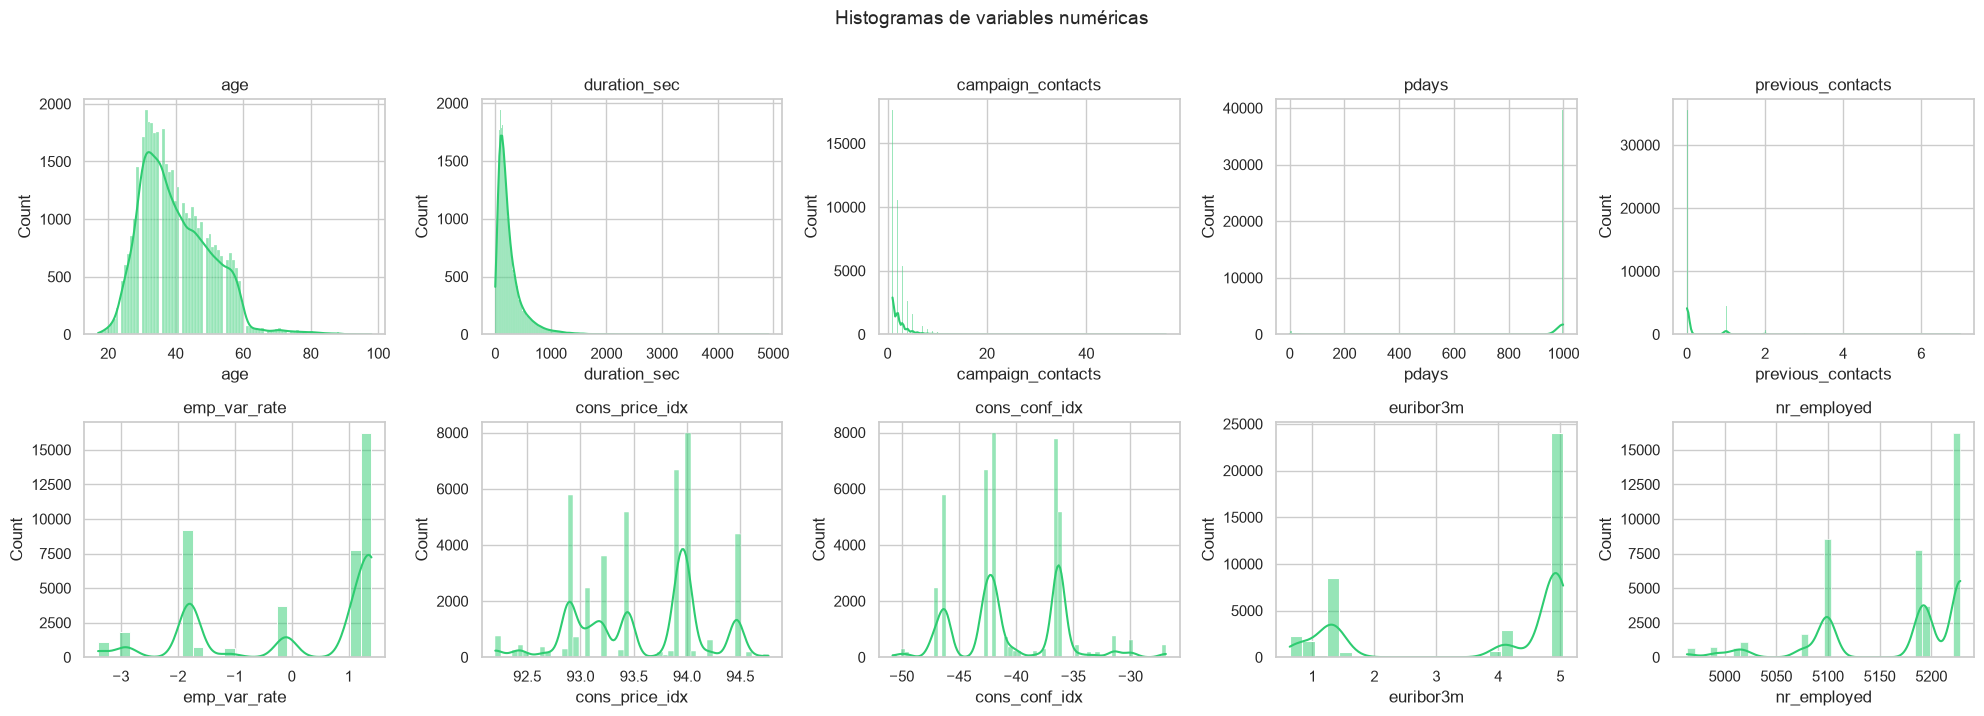

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#2ecc71")
    ax.set_title(col)
plt.suptitle("Histogramas de variables numéricas", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

**Interpretación de histogramas:** `age` se aproxima a una distribución unimodal ligeramente asimétrica a la
derecha (cola de clientes mayores). `duration_sec`, `campaign_contacts` y `previous_contacts` muestran distribuciones
tipo "exponencial decreciente", típicas de variables de conteo/tiempo de espera con muchos valores bajos y pocos
altos — esto sugiere que, si se usaran en un modelo lineal, podría convenir una transformación logarítmica para
reducir la asimetría (a evaluar en la Entrega P2). `pdays` muestra un pico enorme en 999 y una nube dispersa de
valores bajos, confirmando visualmente por qué se separó en un flag binario. Los cinco indicadores macroeconómicos
muestran distribuciones multimodales/discretas: como reflejan el estado de la economía en pocos períodos de tiempo,
en vez de una campana continua se observan "bloques" de valores repetidos (uno por trimestre/mes de campaña).

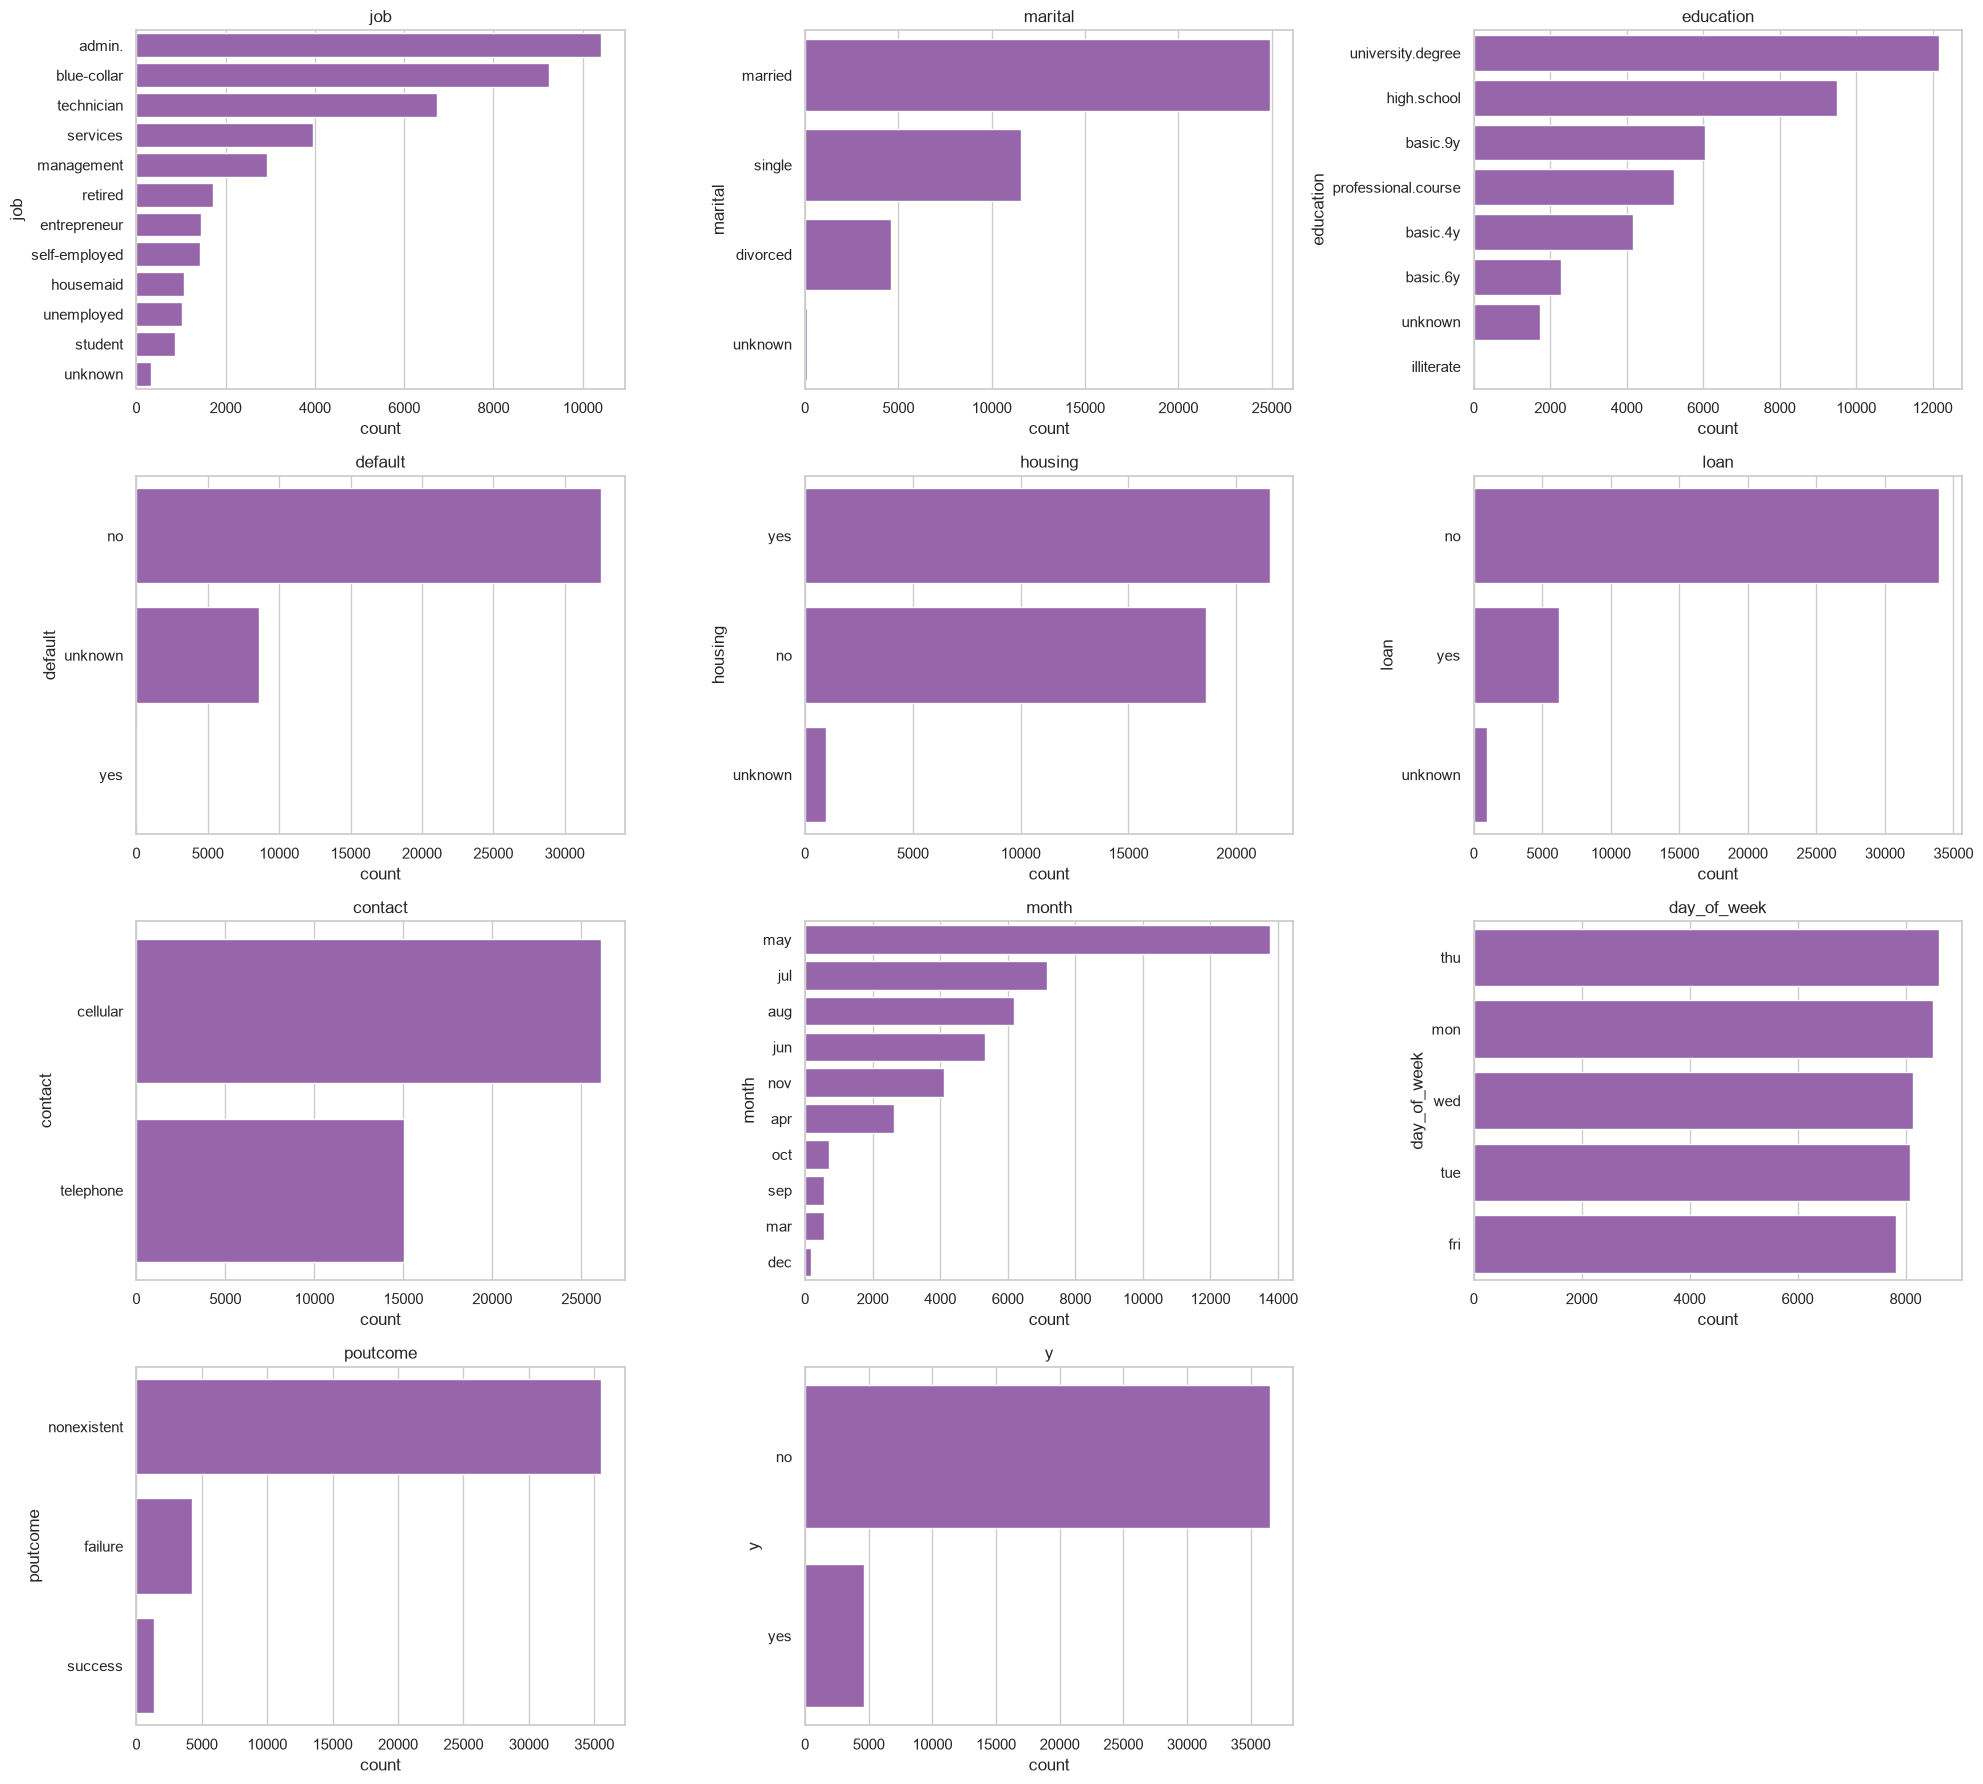

In [ ]:
cat_cols_plot = ["job", "marital", "education", "default", "housing", "loan",
                 "contact", "month", "day_of_week", "poutcome", "y"]

fig, axes = plt.subplots(4, 3, figsize=(20, 18))
axes = axes.flatten()
for ax, col in zip(axes, cat_cols_plot):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=ax, color="#9b59b6")
    ax.set_title(col)
for ax in axes[len(cat_cols_plot):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

**Interpretación de gráficos de barras (categóricas):**
- `job`: dominan `admin.` (10,422) y `blue-collar` (9,254); categorías como `student` y `unemployed` son minoritarias.
- `marital`: `married` concentra ~60% de los clientes, seguido de `single` (~28%) y `divorced` (~11%).
- `education`: `university.degree` es la más común, seguida de `high.school`; `illiterate` es casi inexistente.
- `default`: casi no hay clientes con `yes` (solo 3 registros) — esta variable está extremadamente desbalanceada,
  con la inmensa mayoría en `no` o `unknown`. Su capacidad predictiva real es cuestionable dado este desbalance.
- `housing`/`loan`: distribución relativamente pareja entre `yes`/`no`, con una porción menor de `unknown`.
- `contact`: predominan los contactos por `cellular` (26,144) sobre `telephone` (15,044), reflejando la migración
  hacia teléfonos móviles durante el período de la campaña (2008-2010).
- `month`: `may` concentra ~33% de todos los contactos (13,769 filas) — muy por encima de cualquier otro mes — lo
  que indica una campaña estacional muy concentrada; meses como `dec`, `mar`, `sep`, `oct` casi no aparecen.
- `day_of_week`: distribución bastante uniforme entre lunes y viernes.
- `poutcome`: `nonexistent` domina (86.3%, coherente con el 96.3% de `contactado_antes = no`), seguido de `failure`
  (10.3%) y `success` (solo 3.3%) — muy pocos clientes tuvieron éxito en una campaña anterior.
- `y` (target): fuerte **desbalance de clases** — 88.73% `no` vs. 11.27% `yes`. Esto es un hallazgo crítico para la
  Entrega P2, ya que un modelo ingenuo que siempre prediga `"no"` alcanzaría ~88.7% de *accuracy* sin haber
  aprendido nada; habrá que usar métricas como F1-score y técnicas de balanceo de clases.

In [ ]:
resumen_numerico = df[numeric_cols].agg(["mean", "median"]).T
resumen_numerico["moda"] = df[numeric_cols].mode().iloc[0]
resumen_numerico["std"] = df[numeric_cols].std()
resumen_numerico["var"] = df[numeric_cols].var()
resumen_numerico["rango"] = df[numeric_cols].max() - df[numeric_cols].min()
resumen_numerico["Q1"] = df[numeric_cols].quantile(0.25)
resumen_numerico["Q3"] = df[numeric_cols].quantile(0.75)
resumen_numerico["IQR"] = resumen_numerico["Q3"] - resumen_numerico["Q1"]
resumen_numerico.round(2)

,mean,median,moda,std,var,rango,Q1,Q3,IQR
age,40.02,38.00,31.00,10.42,108.59,81.00,32.00,47.00,15.00
duration_sec,258.32,180.00,85.00,259.31,67239.25,4918.00,102.00,319.00,217.00
campaign_contacts,2.57,2.00,1.00,2.77,7.67,55.00,1.00,3.00,2.00
pdays,962.46,999.00,999.00,186.94,34945.48,999.00,999.00,999.00,0.00
previous_contacts,0.17,0.00,0.00,0.49,0.24,7.00,0.00,0.00,0.00
emp_var_rate,0.08,1.10,1.40,1.57,2.47,4.80,-1.80,1.40,3.20
cons_price_idx,93.58,93.75,93.99,0.58,0.34,2.57,93.08,93.99,0.92
cons_conf_idx,-40.50,-41.80,-36.40,4.63,21.42,23.90,-42.70,-36.40,6.30
euribor3m,3.62,4.86,4.86,1.73,3.01,4.41,1.34,4.96,3.62
nr_employed,5167.03,5191.00,5228.10,72.25,5220.26,264.50,5099.10,5228.10,129.00


**Interpretación de medidas de tendencia central y dispersión:**
- `duration_sec` tiene una desviación estándar (259.3) casi idéntica a su media (258.3), lo cual es la firma
  característica de una distribución exponencial/muy asimétrica — confirma visualmente lo observado en el histograma.
- `campaign_contacts` tiene rango 55 (1 a 56) pero un IQR pequeño (Q3-Q1 ≈ 2), es decir, el 50% central de los
  clientes recibe muy pocos contactos y la variabilidad grande viene de un pequeño grupo de outliers insistentes.
- `pdays` tiene una media (962.5) muy cercana a su valor máximo posible (999), reflejando que casi todos los
  registros están "saturados" en el valor centinela; su desviación estándar (186.9) solo refleja variabilidad
  dentro del ~4% de clientes sí contactados antes.
- Los indicadores macroeconómicos (`emp_var_rate`, `cons_price_idx`, `cons_conf_idx`, `euribor3m`, `nr_employed`)
  tienen rangos pequeños en términos absolutos, coherente con ser tasas/índices que varían poco de un trimestre a
  otro, pero (como se verá en la sección multivariada) están fuertemente correlacionados entre sí.

### 4.b Análisis Multivariado

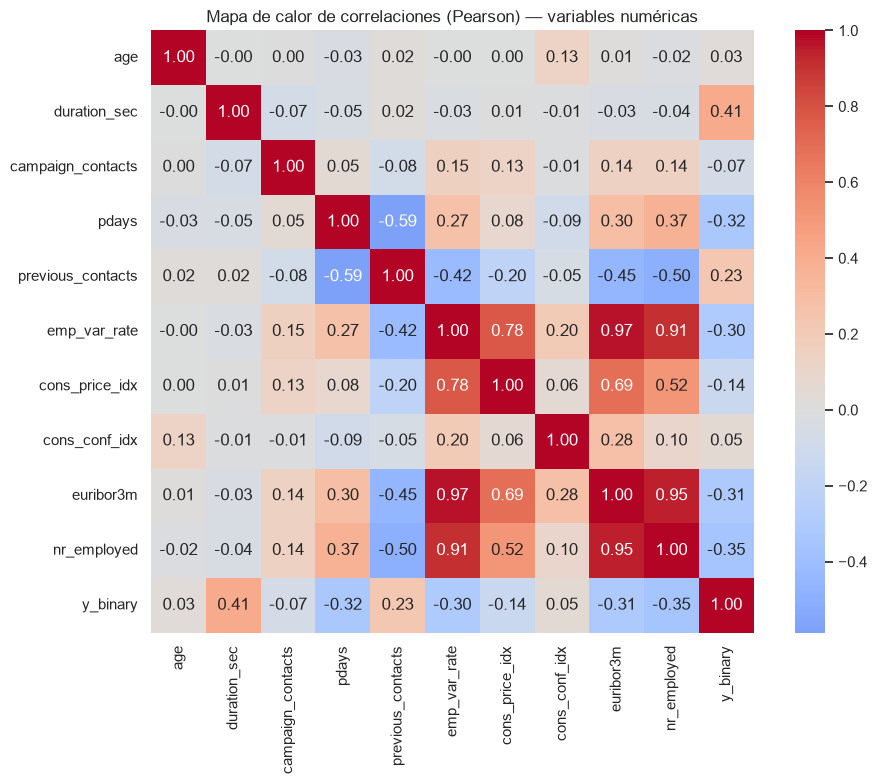

In [ ]:
plt.figure(figsize=(10, 8))
corr_matrix = df[numeric_cols + ["y_binary"]].corr(method="pearson")
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Mapa de calor de correlaciones (Pearson) — variables numéricas")
plt.tight_layout()
plt.show()

**Interpretación del mapa de calor:** se observa un bloque de **alta colinealidad** entre los cinco
indicadores macroeconómicos y `emp_var_rate`:
- `emp_var_rate` vs `euribor3m`: r = 0.97 (casi perfecta)
- `euribor3m` vs `nr_employed`: r = 0.95
- `emp_var_rate` vs `nr_employed`: r = 0.91
- `emp_var_rate` vs `cons_price_idx`: r = 0.78

Esto tiene sentido económico: cuando el empleo cae (emp_var_rate negativo), suele coincidir con tasas de interés
(euríbor) más bajas y menos empleados formales — son indicadores que se mueven juntos en el ciclo económico. Para
la Entrega P2 esto es una señal de alerta de **multicolinealidad**: si se usa un modelo lineal (regresión logística),
convendría descartar o combinar (p. ej. PCA) algunas de estas variables redundantes, mientras que modelos basados
en árboles (Árbol de Decisión, XGBoost) son más robustos a este problema.

Respecto al target `y_binary`, ninguna variable numérica muestra correlación lineal fuerte de forma aislada — la
más notoria es `duration_sec` (positiva, coherente con que llamadas más largas indican mayor interés) y
`nr_employed`/`euribor3m`/`emp_var_rate` (negativas moderadas: campañas en contextos económicos menos favorables
—menor empleo, tasas más bajas— coinciden paradójicamente con más conversiones, posiblemente porque el banco
intensificó/ajustó su oferta de depósitos en esos períodos). Esto sugiere que el poder predictivo real vendrá más
de variables categóricas (`poutcome`, `month`, `contact`) y de interacciones, no de relaciones lineales simples.

In [ ]:
pares_covarianza = [
    ("emp_var_rate", "euribor3m"),
    ("euribor3m", "nr_employed"),
    ("emp_var_rate", "nr_employed"),
    ("emp_var_rate", "cons_price_idx"),
    ("pdays", "previous_contacts"),
]
cov_matrix = df[numeric_cols].cov()
for a, b in pares_covarianza:
    print(f"cov({a}, {b}) = {cov_matrix.loc[a, b]:.3f}   |   corr = {corr_matrix.loc[a, b]:.3f}")

cov(emp_var_rate, euribor3m) = 2.649   |   corr = 0.972
cov(euribor3m, nr_employed) = 118.441   |   corr = 0.945
cov(emp_var_rate, nr_employed) = 102.937   |   corr = 0.907
cov(emp_var_rate, cons_price_idx) = 0.705   |   corr = 0.775
cov(pdays, previous_contacts) = -54.360   |   corr = -0.588


**Interpretación de covarianza vs. correlación:** la covarianza confirma el mismo signo que la correlación
en todos los pares (positivo para los primeros cuatro, negativo para `pdays`/`previous_contacts`), pero su magnitud
no es comparable entre variables porque depende de la escala original de cada una (p. ej. `nr_employed` está en
miles, mientras `euribor3m` está en unidades porcentuales pequeñas). Por eso la **correlación** (que normaliza por
las desviaciones estándar) es la métrica preferida para comparar la fuerza de relación entre distintos pares de
variables, mientras que la covarianza solo nos interesa para confirmar la dirección (signo) de la relación.

/var/folders/8d/zj7wntq938x4bp7vf97gz8d00000gn/T/ipykernel_86706/269924846.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="y", y="duration_sec", ax=axes[0], palette="Set2")
/var/folders/8d/zj7wntq938x4bp7vf97gz8d00000gn/T/ipykernel_86706/269924846.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="y", y="age", ax=axes[1], palette="Set2")
/var/folders/8d/zj7wntq938x4bp7vf97gz8d00000gn/T/ipykernel_86706/269924846.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="y", y="campaign_contacts", ax=axes[2], 

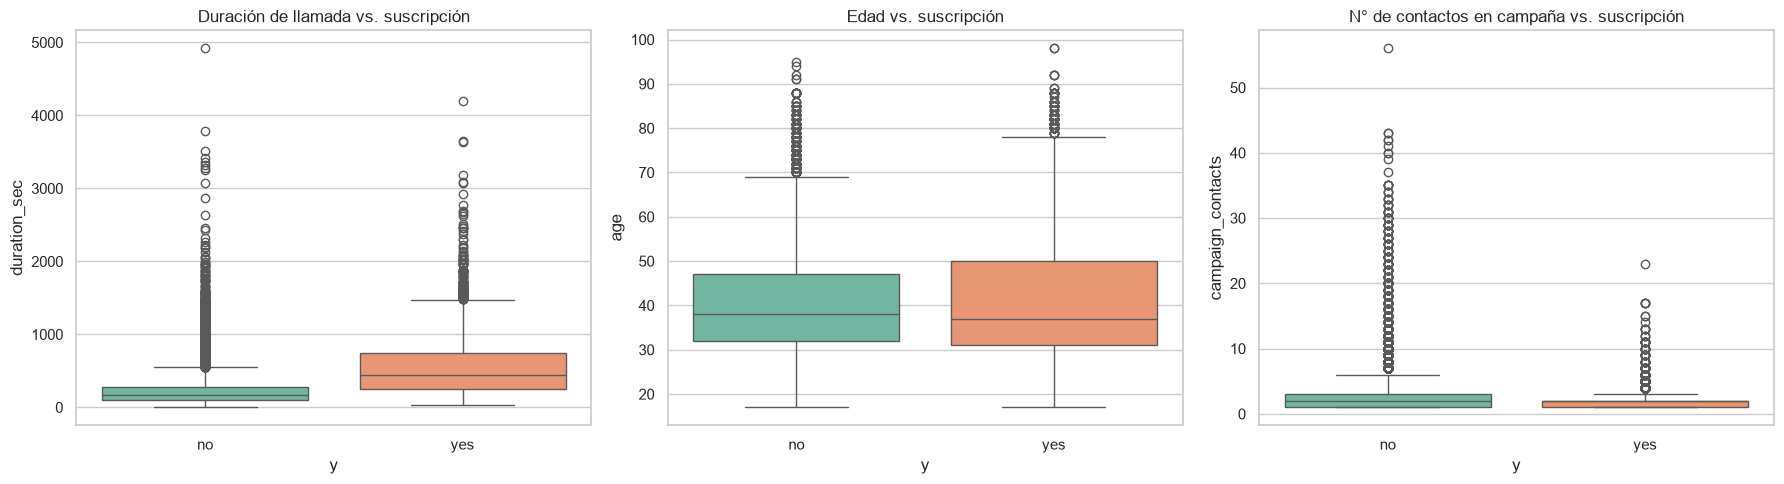

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=df, x="y", y="duration_sec", ax=axes[0], palette="Set2")
axes[0].set_title("Duración de llamada vs. suscripción")
sns.boxplot(data=df, x="y", y="age", ax=axes[1], palette="Set2")
axes[1].set_title("Edad vs. suscripción")
sns.boxplot(data=df, x="y", y="campaign_contacts", ax=axes[2], palette="Set2")
axes[2].set_title("N° de contactos en campaña vs. suscripción")
plt.tight_layout()
plt.show()

**Interpretación (boxplots comparativos):** los clientes que sí suscriben (`y = "yes"`) tienen una mediana de
`duration_sec` visiblemente mayor que los que no suscriben (duración promedio 553s vs. 221s) — confirma la advertencia
inicial sobre esta variable. La distribución de `age` es similar entre ambos grupos, con una mediana ligeramente
superior en el grupo de "no suscriptores" jóvenes-adultos, pero con una cola más pesada de adultos mayores en el
grupo "yes" (los jubilados parecen tener mayor propensión a suscribir depósitos a plazo). `campaign_contacts` tiende
a ser menor entre quienes sí suscriben — es decir, **insistir muchas veces con el mismo cliente se asocia con menor
probabilidad de éxito**, un hallazgo relevante para la estrategia comercial del banco.

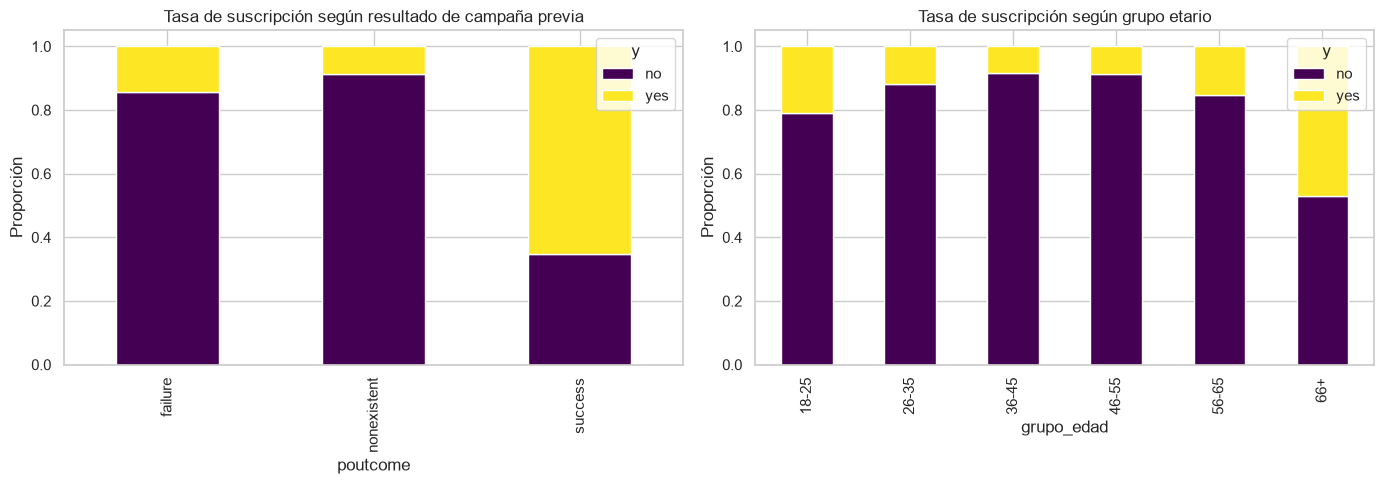

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pd.crosstab(df["poutcome"], df["y"], normalize="index").plot(kind="bar", stacked=True, ax=axes[0], colormap="viridis")
axes[0].set_title("Tasa de suscripción según resultado de campaña previa")
axes[0].set_ylabel("Proporción")

pd.crosstab(df["grupo_edad"], df["y"], normalize="index").plot(kind="bar", stacked=True, ax=axes[1], colormap="viridis")
axes[1].set_title("Tasa de suscripción según grupo etario")
axes[1].set_ylabel("Proporción")
plt.tight_layout()
plt.show()

**Interpretación (barras agrupadas/apiladas):** cuando la campaña previa fue exitosa (`poutcome = "success"`),
la tasa de conversión actual sube dramáticamente a ~65% (894 de 1,373), muy por encima del ~11% promedio general —
es, con diferencia, la señal categórica más fuerte del dataset. Por grupo etario, los extremos (`18-25` y `66+`)
muestran proporciones de "yes" notablemente más altas que los grupos de edad media (`36-55`), sugiriendo que
estudiantes/jóvenes y jubilados son segmentos más receptivos a productos de ahorro, mientras que adultos en edad
laboral típica muestran menor interés (posiblemente por tener otros compromisos financieros como hipotecas).

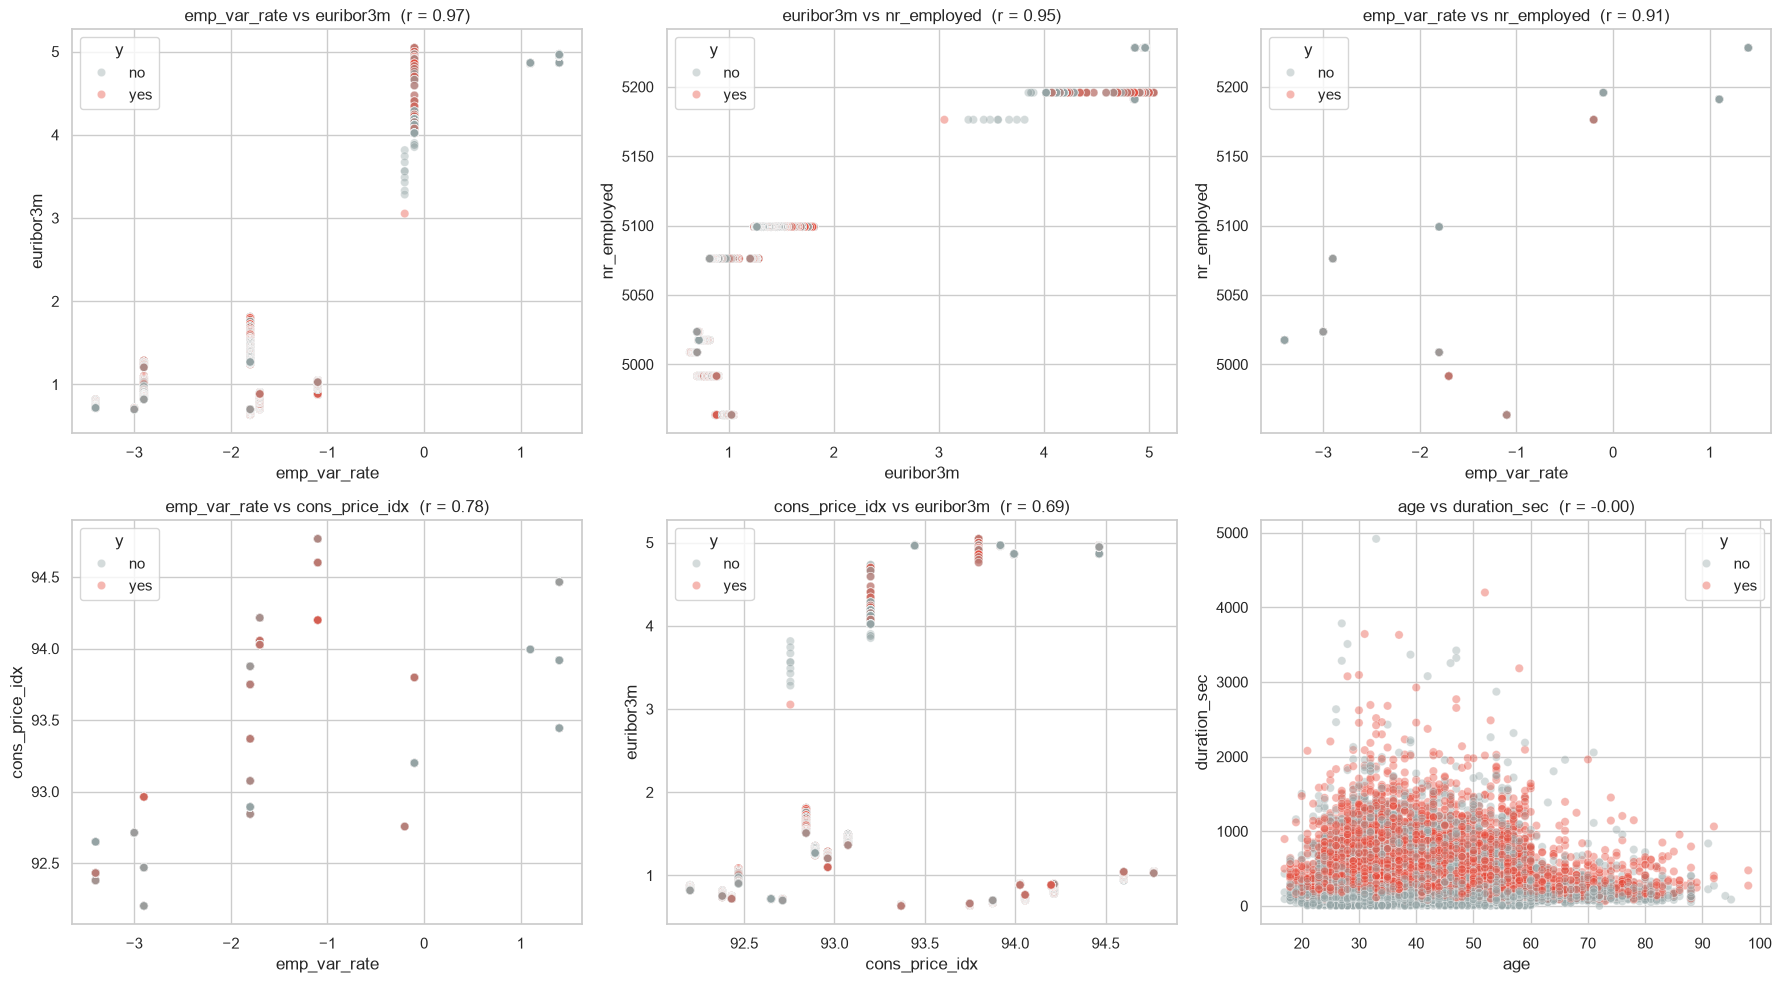

In [ ]:
num_pairs = [
    ("emp_var_rate", "euribor3m"),
    ("euribor3m", "nr_employed"),
    ("emp_var_rate", "nr_employed"),
    ("emp_var_rate", "cons_price_idx"),
    ("cons_price_idx", "euribor3m"),
    ("age", "duration_sec"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, (a, b) in zip(axes, num_pairs):
    sns.scatterplot(data=df, x=a, y=b, hue="y", alpha=0.4, ax=ax, palette={"no": "#95a5a6", "yes": "#e74c3c"})
    r = corr_matrix.loc[a, b]
    ax.set_title(f"{a} vs {b}  (r = {r:.2f})")
plt.tight_layout()
plt.show()

**Interpretación de los diagramas de dispersión:**
1. `emp_var_rate` vs `euribor3m` (r=0.97): relación lineal casi perfecta y positiva — ambas variables suben y bajan
   juntas siguiendo el ciclo económico, formando una nube muy angosta.
2. `euribor3m` vs `nr_employed` (r=0.95): también fuertemente lineal positiva; se ven "clusters" discretos de puntos
   porque ambas variables toman pocos valores únicos (una por período de campaña).
3. `emp_var_rate` vs `nr_employed` (r=0.91): patrón similar, con agrupamientos claros en 3-4 nubes de puntos
   correspondientes a distintos períodos económicos durante la campaña (2008 crisis financiera vs. 2009-2010).
4. `emp_var_rate` vs `cons_price_idx` (r=0.78): relación positiva moderada-fuerte, con más dispersión que los pares
   anteriores — el índice de precios no se mueve tan sincronizadamente con el empleo.
5. `cons_price_idx` vs `euribor3m` (r=0.69): relación positiva moderada, con una nube más dispersa; ambas reflejan
   condiciones económicas pero con dinámicas distintas (precios vs. tasas de interés).
6. `age` vs `duration_sec` (r≈0.00, incluida como contraste): nube de puntos sin ningún patrón lineal reconocible —
   confirma que la duración de la llamada no depende de la edad del cliente, sino de otros factores (interés real
   en el producto). Al colorear por `y`, se observa que los puntos rojos (`yes`) se concentran en duraciones más
   altas independientemente de la edad, reforzando el hallazgo del boxplot comparativo.

En conjunto, los primeros cinco pares muestran claramente el bloque de colinealidad entre los indicadores
macroeconómicos, mientras que el sexto pone en evidencia que no todas las combinaciones de variables numéricas
están relacionadas — es importante mostrar ambos casos para no sobregeneralizar "todo está correlacionado".

In [ ]:
corr_spearman = df[numeric_cols + ["y_binary"]].corr(method="spearman")["y_binary"].drop("y_binary").sort_values(key=abs, ascending=False)
corr_pearson = df[numeric_cols + ["y_binary"]].corr(method="pearson")["y_binary"].drop("y_binary").sort_values(key=abs, ascending=False)

comparacion_corr = pd.DataFrame({"pearson": corr_pearson, "spearman": corr_spearman.reindex(corr_pearson.index)})
comparacion_corr.round(3)

,pearson,spearman
duration_sec,0.405,0.349
nr_employed,-0.355,-0.284
pdays,-0.325,-0.325
euribor3m,-0.308,-0.267
emp_var_rate,-0.298,-0.247
previous_contacts,0.230,0.201
cons_price_idx,-0.136,-0.122
campaign_contacts,-0.066,-0.064
cons_conf_idx,0.055,0.041
age,0.030,-0.012


**Interpretación (Pearson vs. Spearman respecto al target):** ambos coeficientes coinciden en que
`nr_employed`, `euribor3m`, `emp_var_rate` y `pdays` (los cuatro con `contactado_antes` implícito) son las variables
numéricas más asociadas al target — todas negativas, es decir, a menor valor de estos indicadores le corresponde
mayor tasa de suscripción. `duration_sec` muestra una diferencia interesante: su Spearman es mayor que su Pearson,
lo que indica que su relación con el target es monótona pero no estrictamente lineal (coherente con su distribución
altamente asimétrica) — Spearman, al trabajar con rangos, es más robusto a esa asimetría y a outliers que Pearson.

### 4.c Conclusiones Generales del EDA

**Resumen de hallazgos univariados:**
- El target `y` está fuertemente desbalanceado (88.7% "no" vs 11.3% "yes"), lo que deberá abordarse explícitamente
  en el modelamiento (Entrega P2) mediante métricas robustas (F1, matriz de confusión) y/o técnicas de balanceo.
- Varias variables numéricas (`duration_sec`, `campaign_contacts`, `previous_contacts`) tienen distribuciones muy
  asimétricas con outliers legítimos (no son errores de captura), por lo que su tratamiento en el modelado deberá
  considerar transformaciones (log) o modelos robustos a asimetría (árboles).
- `pdays` requiere el tratamiento especial documentado (flag `contactado_antes`) por el valor centinela 999 que
  domina el 96.3% de los registros.
- Categóricamente, `default` está casi sin variabilidad útil (solo 3 "yes" en 41,188 filas) y `month`/`poutcome`
  están muy desbalanceados hacia ciertas categorías (`may`, `nonexistent`).

**Discusión sobre colinealidad y relaciones lineales:**
- Existe un bloque claro de multicolinealidad entre los cinco indicadores socioeconómicos (`emp_var_rate`,
  `euribor3m`, `nr_employed`, `cons_price_idx`, y en menor medida `cons_conf_idx`), con correlaciones de hasta 0.97.
  Este hallazgo es clave para la Entrega P2: usar todas estas variables simultáneamente en un modelo lineal podría
  inflar artificialmente la varianza de los coeficientes; se recomienda evaluar selección de variables, PCA, o
  simplemente confiar en modelos no lineales/basados en árboles que toleran mejor la colinealidad.
- Ninguna variable numérica individual tiene una correlación lineal fuerte con el target — la señal más fuerte
  observada en todo el EDA es categórica (`poutcome = "success"` dispara la tasa de conversión a ~65%).

**Variables clave identificadas para el modelamiento:**
- `poutcome` / `exito_campania_previa` (señal más fuerte y clara).
- `duration_sec` (fuerte relación con el target, pero con la salvedad de fuga de información/leakage ya discutida).
- `contactado_antes` y `previous_contacts` (relacionadas con el historial de contacto del cliente).
- Los indicadores macroeconómicos, tratados en conjunto (posiblemente resumidos en 1-2 componentes) más que de
  forma individual, dado el problema de colinealidad detectado.
- `grupo_edad`, `job`, `month` y `contact`, que mostraron diferencias visibles en tasa de conversión entre categorías.